In [228]:
import numpy as np
import gymnasium as gym
import importlib
import envs

import learners
import analysis
importlib.reload(analysis)
importlib.reload(learners)
from learners import *
from analysis import *

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)

params = Params(
    model_name="CliffSlipperyLow",
    n_runs=1,
    n_episodes=5_000,
    save_skip=50,
    lr_decay=None,
    seed=123,
    
    N=32,
    alpha=1.0,
    gamma=0.99,
    epsilon=0.0,
    kappa=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(
    params.model_name,
    p_random=0.25,
)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

explorer = EpsilonGreedy(rng)

In [233]:
0.25 / 2, 1.0 - 0.25

(0.125, 0.75)

In [4621]:
policy, V_pi = PolicyIteration(env, params.gamma)
returns = MonteCarlo(env, policy, params.gamma, total_episodes=10_000)
tau_returns = np.quantile(np.sort(returns), tau)

100%|██████████| 10000/10000 [00:02<00:00, 4212.74it/s]


In [2727]:
tau = (np.arange(params.N) + 0.5) / params.N

def HL_grad(u, kappa):
    return np.where(np.abs(u) <= kappa, u, kappa * np.sign(u))

def _rho(u):
    return (tau - (u < 0)).mean(0)

theta = np.zeros((params.nS, params.nA, params.N))

def update(s, a, r, sp):
    Ttheta = r + params.gamma * theta[sp, theta[sp].mean(-1).argmax()]
    u = Ttheta[:, None] - theta[s, a][None, :]
    theta[s, a] += 0.05 * _rho(u)

In [4617]:
s, _ = env.reset()
rs = []
done = False
while not done:
    a = policy[s].argmax()
    sp, r, done, _, _ = env.step(a)
    update(s, a, r, sp)
    s = sp
i = 0#12
theta[s_init-i, policy[s_init-i].argmax()].round(3)

array([0.   , 0.003, 0.014, 0.084, 0.287, 0.308, 0.325, 0.344, 0.364,
       0.386, 0.406, 0.436, 0.469, 0.503, 0.539, 0.597, 0.692, 0.769,
       0.778, 0.786, 0.795, 0.805, 0.813, 0.82 , 0.825, 0.83 , 0.834,
       0.841, 0.847, 0.853, 0.861, 0.869])

In [ ]:
# sp = 36
# s = 35
# a = 1

# Ttheta = r + params.gamma * theta[sp, self.get_Q(sp).argmax()]
# u = Ttheta[:, None] - self.theta[s, a][None, :]
# self.theta[s, a] += self.lr * self._rho(u)

In [4622]:
scheduler = get_exp_scheduler(params.alpha, 1250, min_val=0.00025)
table0 = QR(params, policy).train(env, explorer, lambda t: 0.1)

100%|██████████| 5000/5000 [00:11<00:00, 453.09it/s, run=1, t=5000]


In [230]:
qtable = Qlearner(params, policy).train(env, explorer, scheduler)

100%|██████████| 5000/5000 [00:06<00:00, 768.42it/s, run=1, t=5000]


100%|██████████| 5000/5000 [00:01<00:00, 4330.10it/s]


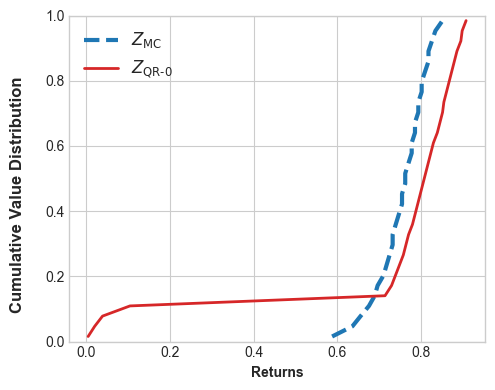

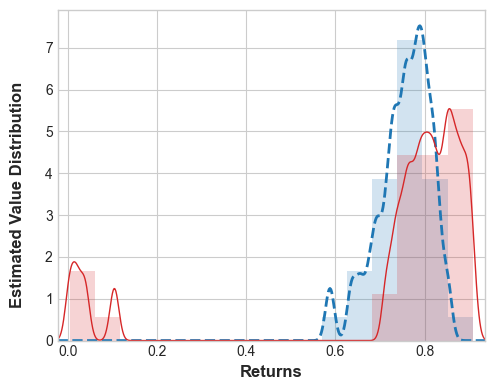

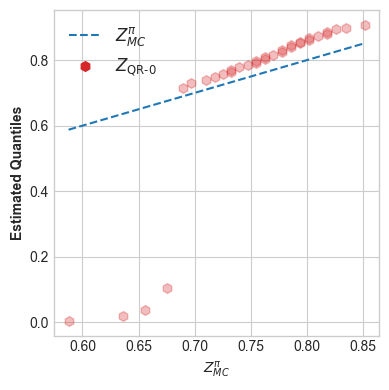

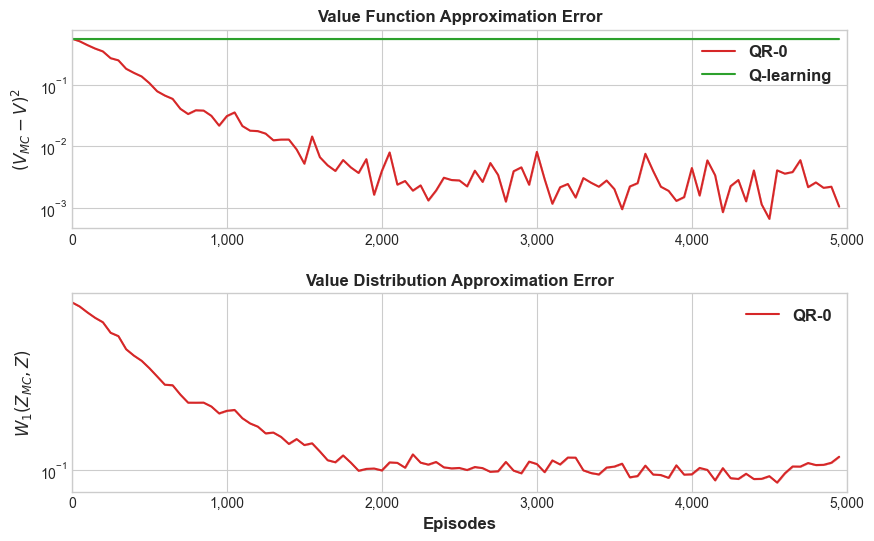

In [4623]:
# save_to = "results/results/"+params.model_name
save_to = None

# def get_q(table): return table[:,:,s_init].max(2)
i = 0

policy, V_pi = PolicyIteration(env, params.gamma)
returns = MonteCarlo(env, policy, params.gamma, s_init=s_init-i, total_episodes=5_000)
tau_returns = np.quantile(np.sort(returns), tau)

def get_q(table): return table[:,:,s_init-i, policy[s_init-i].argmax()]
def get_best(table): return get_q(table)[:,-1].mean(0)

import analysis
importlib.reload(analysis)
from analysis import *

plot_objs = [
    (get_best(table0), r"$Z_{\text{QR-0}}$"),
    # (get_best(table1), r"$Z_{\text{QR-0}}$"),
]
plot_qs = [
    (get_q(table0), "QR-0"),
    # (get_q(table1), "QR-0"),
    (get_q(qtable), "Q-learning"),
]

LOW_BANDWIDTH = 0.004; bw = 0.01

plot_cdf(plot_objs, tau_returns, tau, linewidths=(3,2), save_to=save_to, returns_name=r"$Z_{\text{MC}}$")
plot_pdf(plot_objs, tau_returns, bandwidth=bw, show_hist=True, linewidth=1.0, N=params.N//2, hist_alpha=0.2, save_to=save_to)
plot_qq(plot_objs, tau_returns, save_to=save_to, alpha=0.3, markersize=7)
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.2,0.3], true_dist="{MC}")

In [89]:
s, _ = env.reset()

1 True


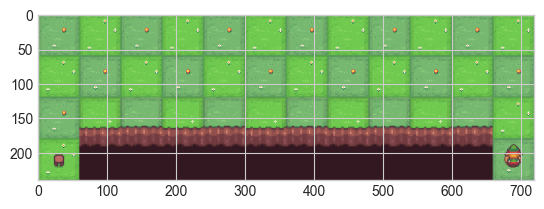

In [145]:
s, r, done, _, _ = env.step(policy[s].argmax())
print(r, done)
plt.imshow(env.render())

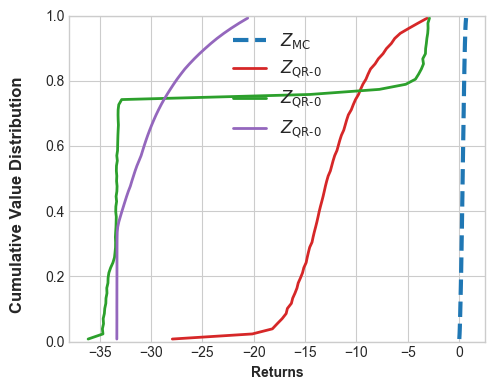

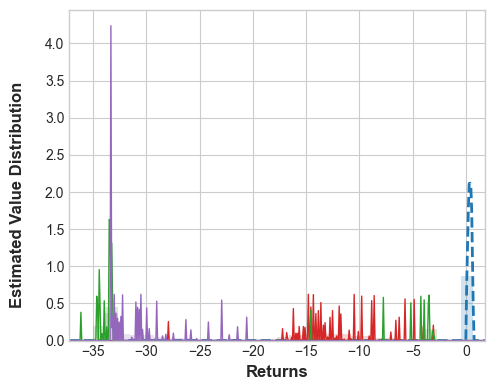

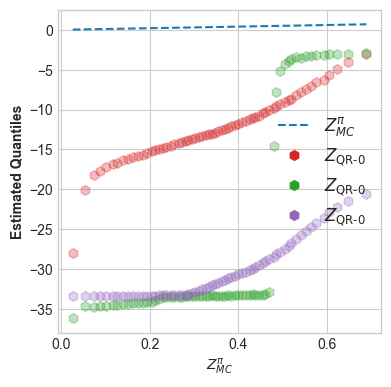

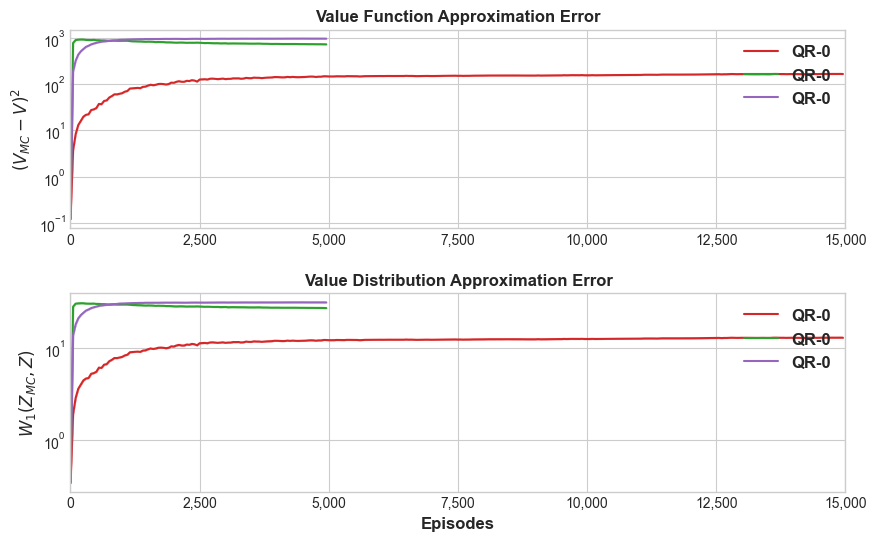

In [280]:
# save_to = "results/results/"+params.model_name
save_to = None

# def get_q(table): return table[:,:,s_init].max(2)
def get_q(table): return table[:,:,s_init, policy[s_init].argmax()]
def get_best(table): return get_q(table)[:,-1].mean(0)

import analysis
importlib.reload(analysis)
from analysis import *

plot_objs = [
    (get_best(table1), r"$Z_{\text{QR-0}}$"),
    (get_best(table2), r"$Z_{\text{QR-0}}$"),
    (get_best(table3), r"$Z_{\text{QR-0}}$"),
]
plot_qs = [
    (get_q(table1), "QR-0"),
    (get_q(table2), "QR-0"),
    (get_q(table3), "QR-0"),
    # (get_q(qtable), "Q-learning"),
]

LOW_BANDWIDTH = 0.004; bw = 0.01

plot_cdf(plot_objs, tau_returns, tau, linewidths=(3,2), save_to=save_to, returns_name=r"$Z_{\text{MC}}$")
plot_pdf(plot_objs, tau_returns, bandwidth=bw, show_hist=True, linewidth=1.0, N=params.N//2, hist_alpha=0.2, save_to=save_to)
plot_qq(plot_objs, tau_returns, save_to=save_to, alpha=0.3, markersize=7)
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.2,0.3], true_dist="{MC}")

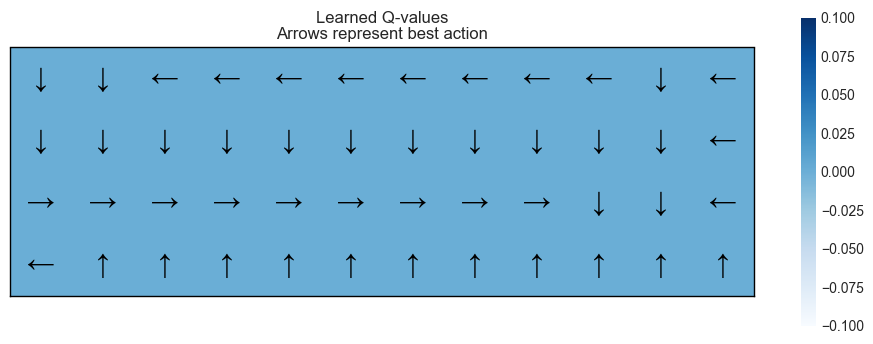

In [266]:
maxi = np.asarray([table1[0,-1].mean(-1)[s, policy[s].argmax()] for s in np.arange(params.nS)])
# Plot max following policy, not qtables.

plot_map(table1[0,-1].mean(-1), params, True)